In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error ,r2_score

In [2]:
df= pd.read_csv(r"C:\Users\mahip\Desktop\Data Science git file\Data-Science\Machine Lerning\project\class\clear_bike_data.csv")

In [3]:

df

,Unnamed: 0,bike_name,price,city,kms_driven,owner,age,power,brand
0,0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha
...,...,...,...,...,...,...,...,...,...
32643,32643,Hero Passion Pro 100cc,39000.0,Delhi,22000.0,First Owner,4.0,100.0,Hero
32644,32644,TVS Apache RTR 180cc,30000.0,Karnal,6639.0,First Owner,9.0,180.0,TVS
32645,32645,Bajaj Avenger Street 220,60000.0,Delhi,20373.0,First Owner,6.0,220.0,Bajaj
32646,32646,Hero Super Splendor 125cc,15600.0,Jaipur,84186.0,First Owner,16.0,125.0,Hero


In [4]:
df.head()

,Unnamed: 0,bike_name,price,city,kms_driven,owner,age,power,brand
0,0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha


In [5]:
df.tail()

,Unnamed: 0,bike_name,price,city,kms_driven,owner,age,power,brand
32643,32643,Hero Passion Pro 100cc,39000.0,Delhi,22000.0,First Owner,4.0,100.0,Hero
32644,32644,TVS Apache RTR 180cc,30000.0,Karnal,6639.0,First Owner,9.0,180.0,TVS
32645,32645,Bajaj Avenger Street 220,60000.0,Delhi,20373.0,First Owner,6.0,220.0,Bajaj
32646,32646,Hero Super Splendor 125cc,15600.0,Jaipur,84186.0,First Owner,16.0,125.0,Hero
32647,32647,Bajaj Pulsar 150cc,22000.0,Pune,60857.0,First Owner,13.0,150.0,Bajaj


In [6]:
df.shape

(32648, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32648 entries, 0 to 32647
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  32648 non-null  int64  
 1   bike_name   32648 non-null  str    
 2   price       32648 non-null  float64
 3   city        32648 non-null  str    
 4   kms_driven  32648 non-null  float64
 5   owner       32648 non-null  str    
 6   age         32648 non-null  float64
 7   power       32648 non-null  float64
 8   brand       32648 non-null  str    
dtypes: float64(4), int64(1), str(4)
memory usage: 2.2 MB


In [8]:
df.describe()

,Unnamed: 0,price,kms_driven,age,power
count,32648.000000,3.264800e+04,32648.000000,32648.000000,32648.000000
mean,16323.500000,6.829542e+04,26344.625184,8.048211,213.511302
std,9424.810131,9.071860e+04,22208.527695,4.031700,134.428868
min,0.000000,4.400000e+03,1.000000,1.000000,100.000000
25%,8161.750000,2.500000e+04,12000.000000,5.000000,150.000000
50%,16323.500000,4.300000e+04,20373.000000,7.000000,150.000000
75%,24485.250000,8.000000e+04,35000.000000,10.000000,220.000000
max,32647.000000,1.900000e+06,750000.000000,63.000000,1800.000000


In [9]:
df['owner'].unique()


<StringArray>
['First Owner', 'Second Owner', 'Third Owner', 'Fourth Owner Or More']
Length: 4, dtype: str

In [10]:
dct_owner ={'First Owner':1, 'Second Owner':2, 'Third Owner':3,
       'Fourth Owner Or More':4}
df['owner']=df['owner'].map(dct_owner)

In [11]:
df

,Unnamed: 0,bike_name,price,city,kms_driven,owner,age,power,brand
0,0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,1,3.0,110.0,TVS
1,1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,1,4.0,350.0,Royal Enfield
2,2,Triumph Daytona 675R,600000.0,Delhi,110.0,1,8.0,675.0,Triumph
3,3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,1,4.0,180.0,TVS
4,4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,1,3.0,150.0,Yamaha
...,...,...,...,...,...,...,...,...,...
32643,32643,Hero Passion Pro 100cc,39000.0,Delhi,22000.0,1,4.0,100.0,Hero
32644,32644,TVS Apache RTR 180cc,30000.0,Karnal,6639.0,1,9.0,180.0,TVS
32645,32645,Bajaj Avenger Street 220,60000.0,Delhi,20373.0,1,6.0,220.0,Bajaj
32646,32646,Hero Super Splendor 125cc,15600.0,Jaipur,84186.0,1,16.0,125.0,Hero


In [12]:
brand_dict = {
     'TVS':1, 'Royal Enfield':2,         'Triumph':3,          'Yamaha':4,
           'Honda':5,            'Hero':6,           'Bajaj':7,          'Suzuki':8,
         'Benelli':9,             'KTM':10,        'Mahindra':11,        'Kawasaki':12,
          'Ducati':13,         'Hyosung':14, 'Harley-Davidson':15,            'Jawa':16,
             'BMW':17,          'Indian':18,         'Rajdoot':19,             'LML':20,
           'Yezdi':21,              'MV':22,           'Ideal':23
}
df['brand']=df['brand'].map(brand_dict)


In [13]:
df.duplicated().sum() 


np.int64(0)

In [14]:
df.isnull().sum()

Unnamed: 0    0
bike_name     0
price         0
city          0
kms_driven    0
owner         0
age           0
power         0
brand         0
dtype: int64

In [15]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,Unnamed: 0,bike_name,price,city,kms_driven,owner,age,power,brand
0,0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,1,3.0,110.0,1
1,1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,1,4.0,350.0,2
2,2,Triumph Daytona 675R,600000.0,Delhi,110.0,1,8.0,675.0,3
3,3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,1,4.0,180.0,1
4,4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,1,3.0,150.0,4
...,...,...,...,...,...,...,...,...,...
32643,32643,Hero Passion Pro 100cc,39000.0,Delhi,22000.0,1,4.0,100.0,6
32644,32644,TVS Apache RTR 180cc,30000.0,Karnal,6639.0,1,9.0,180.0,1
32645,32645,Bajaj Avenger Street 220,60000.0,Delhi,20373.0,1,6.0,220.0,7
32646,32646,Hero Super Splendor 125cc,15600.0,Jaipur,84186.0,1,16.0,125.0,6


In [16]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [17]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,1,3.0,110.0,1
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,1,4.0,350.0,2
2,Triumph Daytona 675R,600000.0,Delhi,110.0,1,8.0,675.0,3
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,1,4.0,180.0,1
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,1,3.0,150.0,4
...,...,...,...,...,...,...,...,...
32643,Hero Passion Pro 100cc,39000.0,Delhi,22000.0,1,4.0,100.0,6
32644,TVS Apache RTR 180cc,30000.0,Karnal,6639.0,1,9.0,180.0,1
32645,Bajaj Avenger Street 220,60000.0,Delhi,20373.0,1,6.0,220.0,7
32646,Hero Super Splendor 125cc,15600.0,Jaipur,84186.0,1,16.0,125.0,6


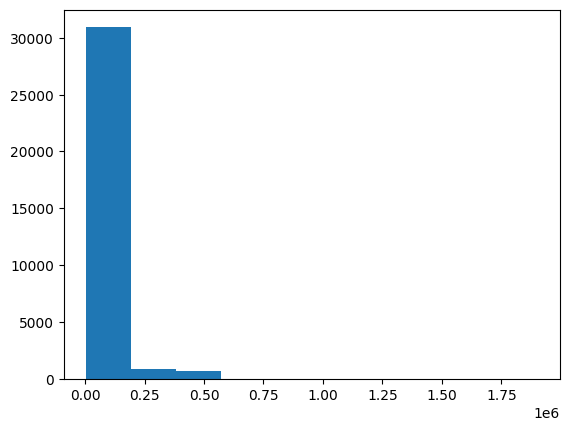

In [18]:
plt.hist(df['price'])
plt.show()

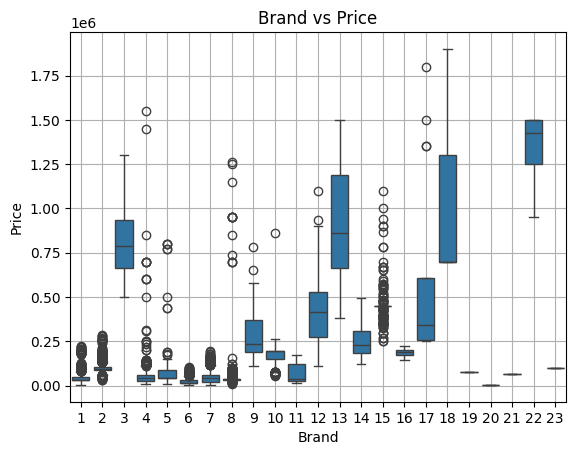

In [19]:
sns.boxplot(x='brand', y='price', data=df)

plt.title("Brand vs Price")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.grid(True)
plt.show()

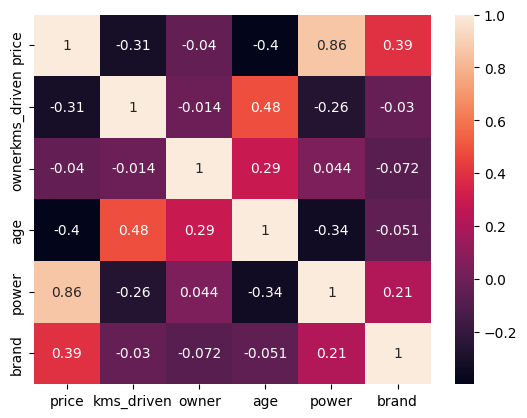

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,1,3.0,110.0,1
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,1,4.0,350.0,2
2,Triumph Daytona 675R,600000.0,Delhi,110.0,1,8.0,675.0,3
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,1,4.0,180.0,1
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,1,3.0,150.0,4
...,...,...,...,...,...,...,...,...
32643,Hero Passion Pro 100cc,39000.0,Delhi,22000.0,1,4.0,100.0,6
32644,TVS Apache RTR 180cc,30000.0,Karnal,6639.0,1,9.0,180.0,1
32645,Bajaj Avenger Street 220,60000.0,Delhi,20373.0,1,6.0,220.0,7
32646,Hero Super Splendor 125cc,15600.0,Jaipur,84186.0,1,16.0,125.0,6


In [23]:
x = df[["brand","owner","kms_driven","age","power"]]
y = df[['price']]

In [24]:
x

,brand,owner,kms_driven,age,power
0,1,1,17654.0,3.0,110.0
1,2,1,11000.0,4.0,350.0
2,3,1,110.0,8.0,675.0
3,1,1,16329.0,4.0,180.0
4,4,1,10000.0,3.0,150.0
...,...,...,...,...,...
32643,6,1,22000.0,4.0,100.0
32644,1,1,6639.0,9.0,180.0
32645,7,1,20373.0,6.0,220.0
32646,6,1,84186.0,16.0,125.0


In [25]:
y

,price
0,35000.0
1,119900.0
2,600000.0
3,65000.0
4,80000.0
...,...
32643,39000.0
32644,30000.0
32645,60000.0
32646,15600.0


In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
x_train.shape, y_train.shape , x_test.shape, y_test.shape

((26118, 5), (26118, 1), (6530, 5), (6530, 1))

In [28]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 5)","[[ 7596.98,-10359.33, -0.24, -2048.25, 518.39]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['brand','owner','kms_driven','age','power']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-52492.72]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [29]:
prediction = model.predict(x_test)

print("MAE =",mean_absolute_error(y_test,prediction))
print("R2 =",r2_score(y_test,prediction))

MAE = 23060.0419791116
R2 = 0.7808546293943639


In [30]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [31]:
import joblib
joblib.dump(model, "bike_price_model.pkl")

['bike_price_model.pkl']

In [32]:
model = joblib.load("bike_price_model.pkl")

In [35]:
new_bike = [[6,	1,	22000.0,	4.0,	100.0]]
price = model.predict(new_bike)
print(price)

[[21011.69172929]]


c:\Users\mahip\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
from sklearn.naive_bayes import GaussianNB , BernoulliNB , MultinomialNB

# GaussianNB
from sklearn.datasets import load_diabetes , load_breast_cancer
x , y = load_diabetes(return_X_y=True)
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42) 


In [37]:
x 

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [38]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [39]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((353, 10), (89, 10), (353,), (89,))

In [40]:
bnb = BernoulliNB()
bnb.fit(x_train , y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](199,)","[1.,1.,2.,...,1.,1.,1.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](199,)","[-5.87,-5.87,-5.17,...,-5.87,-5.87,-5.87]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[float64](199,)","[ 25., 31., 39.,...,336.,341.,346.]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](199, 10)","[[0.,0.,0.,...,0.,0.,0.], [1.,0.,0.,...,0.,0.,0.], [1.,1.,0.,...,0.,0.,1.], ..., [1.,1.,1.,...,0.,1.,1.], [1.,1.,1.,...,1.,1.,1.], [0.,0.,1.,...,1.,1.,1.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](199, 10)","[[-1.1 ,-1.1 ,-1.1 ,...,-1.1 ,-1.1 ,-1.1 ], [-0.41,-1.1 ,-1.1 ,...,-1.1 ,-1.1 ,-1.1 ], [-0.69,-0.69,-1.39,...,-1.39,-1.39,-0.69], ..., [-0.41,-0.41,-0.41,...,-1.1 ,-0.41,-0.41], [-0.41,-0.41,-0.41,...,-0.41,-0.41,-0.41], [-1.1 ,-1.1 ,-0.41,...,-0.41,-0.41,-0.41]]"


In [41]:
x_train

array([[ 0.07076875,  0.05068012,  0.01211685, ...,  0.03430886,
         0.02736405, -0.0010777 ],
       [-0.00914709,  0.05068012, -0.01806189, ...,  0.07120998,
         0.00027248,  0.01963284],
       [ 0.00538306, -0.04464164,  0.04984027, ..., -0.00259226,
         0.01703607, -0.01350402],
       ...,
       [ 0.03081083, -0.04464164, -0.02021751, ..., -0.03949338,
        -0.01090325, -0.0010777 ],
       [-0.01277963, -0.04464164, -0.02345095, ..., -0.00259226,
        -0.03845972, -0.03835666],
       [-0.09269548, -0.04464164,  0.02828403, ..., -0.03949338,
        -0.00514219, -0.0010777 ]], shape=(353, 10))

In [42]:
y_train

array([144., 150., 280., 125.,  59.,  65., 281., 277., 167.,  90.,  72.,
       178.,  88., 270., 101., 197.,  97.,  53.,  71., 262.,  52., 102.,
       166., 189., 173., 220., 206.,  97.,  60.,  61., 242., 121., 128.,
       104., 265., 132., 283., 174., 129., 257., 137.,  63.,  93., 232.,
       208., 261., 179., 258., 262.,  51., 237.,  71., 139., 268.,  69.,
       317., 249., 154., 192., 116.,  81., 122., 259., 191., 292.,  55.,
       107., 210.,  91., 253.,  85., 252.,  59.,  78., 200.,  78., 245.,
       175.,  42., 127.,  53.,  94., 104., 199., 265., 281., 248., 257.,
       215., 303., 170.,  59., 277., 209., 138., 198., 124.,  96., 288.,
       225., 265., 101.,  55., 198.,  51., 252.,  64., 220., 131., 212.,
       142., 103., 155., 121.,  86., 111.,  65., 131.,  51., 128., 141.,
        48., 109., 178.,  88.,  84., 216., 150.,  60.,  96., 190.,  74.,
       279., 182., 160., 245., 276., 174., 180., 150., 196., 138.,  97.,
       246., 321., 308., 109.,  69., 182., 258., 16

In [43]:
bnb.score(x_train , y_train)

0.20113314447592068

In [44]:
from sklearn.naive_bayes import GaussianNB , BernoulliNB , MultinomialNB
# GaussianNB
from sklearn.datasets import load_diabetes , load_breast_cancer
x , y = load_diabetes(return_X_y=True)
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42) 


In [45]:
x

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [46]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [47]:
gau = GaussianNB()
gau.fit(x_train , y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](199,)","[1.,1.,2.,...,1.,1.,1.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](199,)","[0. ,0. ,0.01,...,0. ,0. ,0. ]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[float64](199,)","[ 25., 31., 39.,...,336.,341.,346.]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.343e-12
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](199, 10)","[[-0.02,-0.04,-0.01,...,-0.04,-0.02,-0.03], [ 0. ,-0.04,-0.01,...,-0.04,-0.06,-0.05], [ 0. , 0. ,-0.03,...,-0.06,-0.07, 0.01], ..., [ 0.03, 0.05, 0.11,...,-0. , 0.03, 0.07], [ 0.03, 0.05, 0.13,..., 0.11, 0. , 0.03], [-0.05,-0.04, 0.16,..., 0.03, 0.03, 0.01]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](199, 10)","[[0.,0.,0.,...,0.,0.,0.], [0.,0.,0.,...,0.,0.,0.], [0.,0.,0.,...,0.,0.,0.], ..., [0.,0.,0.,...,0.,0.,0.], [0.,0.,0.,...,0.,0.,0.], [0.,0.,0.,...,0.,0.,0.]]"


In [48]:
x_train

array([[ 0.07076875,  0.05068012,  0.01211685, ...,  0.03430886,
         0.02736405, -0.0010777 ],
       [-0.00914709,  0.05068012, -0.01806189, ...,  0.07120998,
         0.00027248,  0.01963284],
       [ 0.00538306, -0.04464164,  0.04984027, ..., -0.00259226,
         0.01703607, -0.01350402],
       ...,
       [ 0.03081083, -0.04464164, -0.02021751, ..., -0.03949338,
        -0.01090325, -0.0010777 ],
       [-0.01277963, -0.04464164, -0.02345095, ..., -0.00259226,
        -0.03845972, -0.03835666],
       [-0.09269548, -0.04464164,  0.02828403, ..., -0.03949338,
        -0.00514219, -0.0010777 ]], shape=(353, 10))

In [49]:
y_train

array([144., 150., 280., 125.,  59.,  65., 281., 277., 167.,  90.,  72.,
       178.,  88., 270., 101., 197.,  97.,  53.,  71., 262.,  52., 102.,
       166., 189., 173., 220., 206.,  97.,  60.,  61., 242., 121., 128.,
       104., 265., 132., 283., 174., 129., 257., 137.,  63.,  93., 232.,
       208., 261., 179., 258., 262.,  51., 237.,  71., 139., 268.,  69.,
       317., 249., 154., 192., 116.,  81., 122., 259., 191., 292.,  55.,
       107., 210.,  91., 253.,  85., 252.,  59.,  78., 200.,  78., 245.,
       175.,  42., 127.,  53.,  94., 104., 199., 265., 281., 248., 257.,
       215., 303., 170.,  59., 277., 209., 138., 198., 124.,  96., 288.,
       225., 265., 101.,  55., 198.,  51., 252.,  64., 220., 131., 212.,
       142., 103., 155., 121.,  86., 111.,  65., 131.,  51., 128., 141.,
        48., 109., 178.,  88.,  84., 216., 150.,  60.,  96., 190.,  74.,
       279., 182., 160., 245., 276., 174., 180., 150., 196., 138.,  97.,
       246., 321., 308., 109.,  69., 182., 258., 16